In [78]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from typing import List
from tqdm import tqdm
import random
import seaborn as sns
import pandas as pd

1.  Считать данные по ссылке (см выше)
2. Провести EDA  (разведочный анализ данных)
3.  сформировать набор данных для обучения
4. Разделить на train/test  (test - последняя неделя)
5. Сделать рекомендации:
5.1. Random
5.2. Popular
5.3. TopPopular ( personal popular + Popular)

Метрика MAP@10

In [79]:
df_users = pd.read_csv('KION_DATASET/data_original/users.csv')
df_interactions = pd.read_csv('KION_DATASET/interactions.csv')
df_items = pd.read_csv('KION_DATASET/data_original/items.csv')

In [80]:
df_interactions.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250.0,72.0
1,699317,1659,2021-05-29,8317.0,100.0
2,656683,7107,2021-05-09,10.0,0.0
3,864613,7638,2021-07-05,14483.0,100.0
4,964868,9506,2021-04-30,6725.0,100.0


In [81]:
df_users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [82]:
df_items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


<h2>EDA

In [83]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 non-null  float64
 9   studios       1065 non-null   object 
 10  directors     14454 non-null  object 
 11  actors        13344 non-null  object 
 12  description   15961 non-null  object 
 13  keywords      15540 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 1.7+ MB


In [84]:
df_interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594787 entries, 0 to 1594786
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   user_id        1594787 non-null  int64  
 1   item_id        1594787 non-null  int64  
 2   last_watch_dt  1594787 non-null  object 
 3   total_dur      1594786 non-null  float64
 4   watched_pct    1594519 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 60.8+ MB


In [85]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   840197 non-null  int64 
 1   age       826102 non-null  object
 2   income    825421 non-null  object
 3   sex       826366 non-null  object
 4   kids_flg  840197 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 32.1+ MB


In [86]:
print("\nItems Description:")
print(df_items.describe())

print("\nInteractions Description:")
print(df_interactions.describe())

print("\nUsers Description:")
print(df_users.describe())


Items Description:
            item_id  release_year    for_kids    age_rating
count  15963.000000  15865.000000  566.000000  15961.000000
mean    8268.453424   2007.932241    0.201413     12.945555
std     4773.841513     16.881118    0.401411      5.495998
min        0.000000   1897.000000    0.000000      0.000000
25%     4141.500000   2007.000000    0.000000     12.000000
50%     8266.000000   2014.000000    0.000000     16.000000
75%    12414.500000   2018.000000    0.000000     16.000000
max    16518.000000   2021.000000    1.000000     21.000000

Interactions Description:
            user_id       item_id     total_dur   watched_pct
count  1.594787e+06  1.594787e+06  1.594786e+06  1.594519e+06
mean   5.493087e+05  8.484388e+03  8.275508e+03  4.636561e+01
std    3.165523e+05  4.741063e+03  3.326120e+04  4.191284e+01
min    0.000000e+00  0.000000e+00  1.000000e+00  0.000000e+00
25%    2.752460e+05  4.322000e+03  3.710000e+02  4.000000e+00
50%    5.500740e+05  8.776000e+03  2.9000

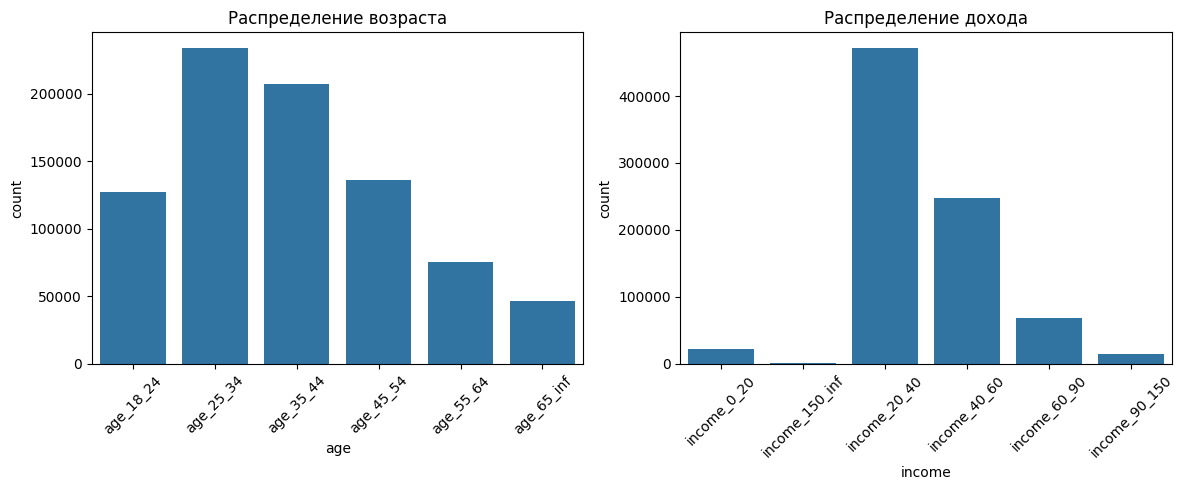

In [87]:
# Гистограммы с распределением возраста и дохода
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_users, x='age', order=sorted(df_users['age'].dropna().unique()))
plt.title('Распределение возраста')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.countplot(data=df_users, x='income', order=sorted(df_users['income'].dropna().unique()))
plt.title('Распределение дохода')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

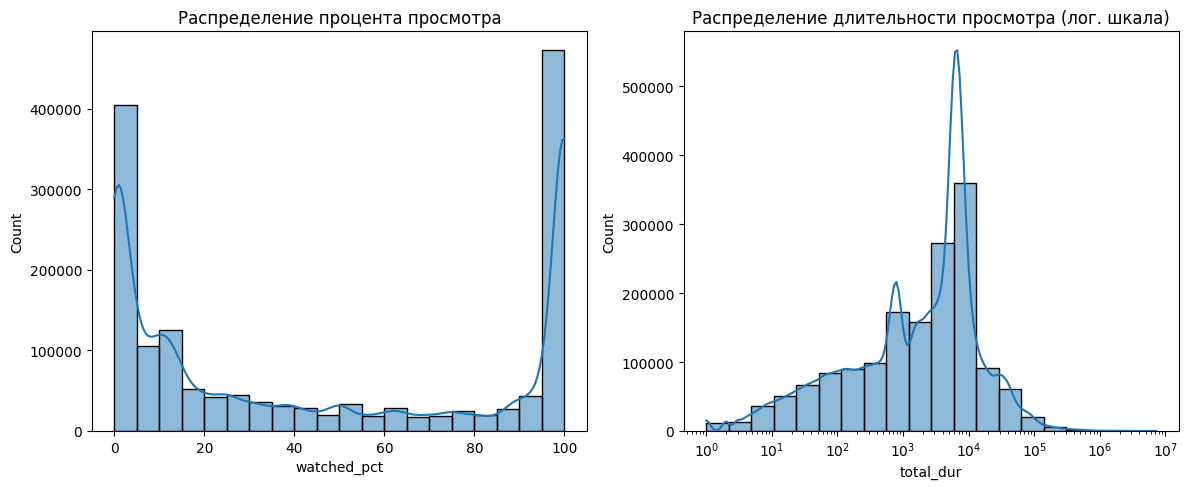

In [88]:
# Визуализация процента просмотра и длительности
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_interactions['watched_pct'], bins=20, kde=True)
plt.title('Распределение процента просмотра')
plt.subplot(1, 2, 2)
sns.histplot(df_interactions['total_dur'], bins=20, kde=True, log_scale=True)
plt.title('Распределение длительности просмотра (лог. шкала)')
plt.tight_layout()
plt.show()

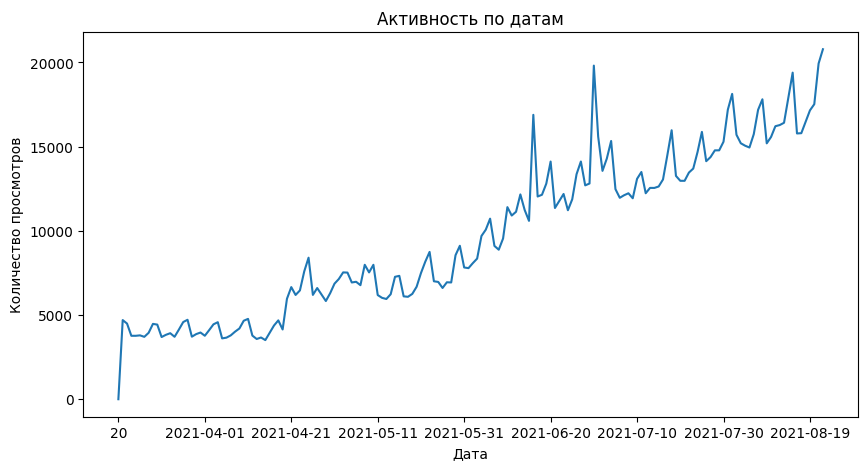

In [89]:
df_interactions['last_watch_dt'].value_counts().sort_index().plot(figsize=(10, 5), title='Активность по датам')
plt.xlabel('Дата')
plt.ylabel('Количество просмотров')
plt.show()

In [90]:
# Общая статистика
print("\n=== Объединенный анализ ===")
merged = df_interactions.merge(df_users, on='user_id', how='left')
print("\nСредний % просмотра по возрасту:\n", merged.groupby('age')['watched_pct'].mean())
print("\nСредняя длительность по доходу:\n", merged.groupby('income')['total_dur'].mean())
print("\nСредний % просмотра по детям:\n", merged.groupby('kids_flg')['watched_pct'].mean())
print("\nСредний % просмотра по полу:\n", merged.groupby('sex')['watched_pct'].mean())


=== Объединенный анализ ===

Средний % просмотра по возрасту:
 age
age_18_24     46.043834
age_25_34     47.247716
age_35_44     47.521189
age_45_54     45.259258
age_55_64     43.076155
age_65_inf    40.033114
Name: watched_pct, dtype: float64

Средняя длительность по доходу:
 income
income_0_20        7076.551466
income_150_inf    12082.360615
income_20_40       7240.968511
income_40_60       7916.290080
income_60_90       9122.344623
income_90_150      9486.656524
Name: total_dur, dtype: float64

Средний % просмотра по детям:
 kids_flg
0.0    45.249022
1.0    47.913714
Name: watched_pct, dtype: float64

Средний % просмотра по полу:
 sex
Ж    46.480759
М    45.886042
Name: watched_pct, dtype: float64


In [91]:
numeric_cols = merged.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = merged[numeric_cols].corr()
print("\nКорреляции:\n", corr_matrix)


Корреляции:
               user_id   item_id  total_dur  watched_pct  kids_flg
user_id      1.000000 -0.000219  -0.000498    -0.001030  0.004366
item_id     -0.000219  1.000000   0.025535     0.028282  0.003447
total_dur   -0.000498  0.025535   1.000000     0.186691  0.007046
watched_pct -0.001030  0.028282   0.186691     1.000000  0.029906
kids_flg     0.004366  0.003447   0.007046     0.029906  1.000000


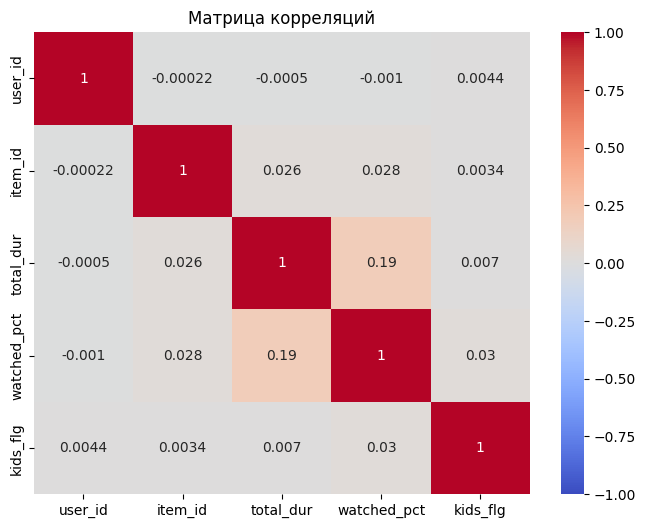

In [92]:
# Создание матрицы корреляции
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций')
plt.show()

<h2>Формирование набора данных для обучения

In [93]:
df_interactions['last_watch_dt'].unique()
df_interactions['last_watch_dt'] = pd.to_datetime(df_interactions['last_watch_dt'], errors='coerce')
df_interactions = df_interactions.dropna(subset=['last_watch_dt'])

In [95]:
from datetime import datetime, timedelta
test_size_days = 10

# Тестовый промежуток времени равен 10 дней
max_date = df_interactions['last_watch_dt'].max()
test_start = max_date - timedelta(days=test_size_days)

df_interactions = df_interactions[(df_interactions['watched_pct']>50.0)] # уберем фильмы с просмотром менее 50%
df_interactions_train = df_interactions[df_interactions['last_watch_dt'] < test_start]
df_interactions_test = df_interactions[df_interactions['last_watch_dt'] >= test_start]


In [96]:
train_sorted = df_interactions_train.sort_values(['user_id', 'last_watch_dt'])
    
train = train_sorted.groupby('user_id').tail(15) # у пользователей в train берем последние 15 фильмов

In [97]:
# Берем толлько активных пользователей. Если брать всех, то оценка будет не объективной.
def get_active_users_ids(df, min_interactions=2):
    """Возвращает ID пользователей, у которых больше минимального числа взаимодействий."""
    counts = df['user_id'].value_counts()
    return set(counts[counts >= min_interactions].index)

# 1. Находим активных пользователей в каждом наборе данных
active_train_ids = get_active_users_ids(train)
active_test_ids = get_active_users_ids(df_interactions_test)

# 2. Находим пересечение (пользователи, активные и в train, и в test)
common_active_users = active_train_ids & active_test_ids

# 3. Фильтруем исходные данные, оставляя только общих активных пользователей
df_interactions_train = train[train['user_id'].isin(common_active_users)]
df_interactions_test = df_interactions_test[df_interactions_test['user_id'].isin(common_active_users)]

In [98]:
def precision(recommended_list, bought_list):
    recommended = np.array(recommended_list)
    bought = np.array(bought_list)

    # флаги: какие рекомендованные товары действительно куплены
    flags = np.isin(recommended, bought)

    return flags.sum() / len(recommended)


def precision_at_k(recommended_list, bought_list, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)

    flags = np.isin(recommended, bought)

    return flags.sum() / k


def money_precision_at_k(recommended_list, bought_list, prices_recommended, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)
    prices = np.array(prices_recommended[:k])

    # флаги: куплен ли товар
    flags = np.isin(recommended, bought)

    # учитываем деньги
    return np.dot(flags, prices) / prices.sum()

In [99]:
def recall(recommended_list, bought_list):
    recommended = np.array(recommended_list)
    bought = np.array(bought_list)

    # какие купленные товары были среди рекомендованных
    flags = np.isin(bought, recommended)

    return flags.sum() / len(bought)


def recall_at_k(recommended_list, bought_list, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)

    flags = np.isin(bought, recommended)

    return flags.sum() / len(bought)


def money_recall_at_k(recommended_list, bought_list, prices_recommended, prices_bought, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)
    prices_bought = np.array(prices_bought)

    # флаги: купленный товар есть в топ-k рекомендациях
    flags = np.isin(bought, recommended)

    # учитываем деньги (важны цены купленных товаров)
    return np.dot(flags, prices_bought) / prices_bought.sum()

In [100]:
def ap_k(recommended_list, bought_list, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)

    # релевантность: рекомендованный товар куплен или нет
    flags = np.isin(recommended, bought)

    # если нет ни одного релевантного — AP = 0
    if flags.sum() == 0:
        return 0

    sum_precision = 0

    for i in range(k):
        if flags[i]:
            # precision@i+1 (на префиксе)
            precision_i = np.isin(recommended[:i+1], bought).sum() / (i + 1)
            sum_precision += precision_i

    # нормируем на число релевантных объектов в топ-k
    return sum_precision / flags.sum()


def map_k(recommended_list, bought_list, k=5, u=1):
    
    # your_code
    if u == 1:
        return ap_k(recommended_list[u-1], bought_list[u-1], k=5)
    
    sum = 0
    for i in range(0, u):
        ap_k_map = ap_k(recommended_list[i], bought_list[i], k=5)
        sum += ap_k_map

    result = sum / u
    
    return result

In [101]:
data_test_group = df_interactions_test.groupby(df_interactions_test['user_id'])['item_id'].unique().reset_index()
data_test_group.columns = ['user_id', 'item_id']
data_test_group

,user_id,item_id
0,259,"[10509, 10772]"
1,655,"[11188, 5199]"
2,753,"[9327, 8350]"
3,835,"[5434, 11640, 10878]"
4,960,"[8636, 12770, 6809]"
...,...,...
5049,1096841,"[10219, 3620]"
5050,1097296,"[3006, 16087]"
5051,1097444,"[13650, 12841, 13099, 1124, 12250, 2483]"
5052,1097459,"[11844, 7793]"


In [102]:
userids = data_test_group['user_id'].values
 
userids_test = np.arange(len(userids))

<h2> Random

In [103]:
def generate_random_recommendations(df_users, df_items, top_n=10, seed=42):
    """
    Генерирует случайные рекомендации для уникальных пользователей.
    """
    np.random.seed(seed)
    
    # 1. Получаем уникальных пользователей и все доступные товары
    unique_users = df_users['user_id'].unique()
    all_items = df_items['item_id'].unique()
    
    # 2. Защита: если товаров меньше, чем нужно рекомендовать
    k = min(top_n, len(all_items))
    
    # 3. Генерируем рекомендации в виде словаря {user_id: [items]}
    # Это быстрее и безопаснее, чем цикл с append
    recommendations_map = {
        user: np.random.choice(all_items, size=k, replace=False).tolist()
        for user in unique_users
    }
    
    # 4. Создаем копию датафрейма и мапим рекомендации по user_id
    result = df_users.copy()
    result['random_recommendation'] = result['user_id'].map(recommendations_map)
    
    return result

# Использование
result_random = generate_random_recommendations(
    df_users=data_test_group, 
    df_items=df_interactions, 
    top_n=10
)

In [104]:
# items взять из тестового набора



print('random map_k =', map_k(result_random['random_recommendation'], result_random['item_id'], k=10, u=len(result_random)))


print(map_k)

random map_k = 0.0008508112386228731
<function map_k at 0x000001AD2A44E560>


<h2> Popular

In [105]:
def get_popular_items(train, n=10):
    """Возвращает список из n самых популярных товаров."""
    top_items = train['item_id'].value_counts().nlargest(n)
    return top_items.index.tolist()

# 1. Получаем список популярных товаров (длиной 10)
popular = get_popular_items(df_interactions_train, n=10)

# 2. Присваиваем рекомендации
result_popular = data_test_group.copy()

result_popular['popular_recommendation'] = [popular] * len(result_popular)

In [106]:
result_popular

,user_id,item_id,popular_recommendation
0,259,"[10509, 10772]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."
1,655,"[11188, 5199]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."
2,753,"[9327, 8350]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."
3,835,"[5434, 11640, 10878]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."
4,960,"[8636, 12770, 6809]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."
...,...,...,...
5049,1096841,"[10219, 3620]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."
5050,1097296,"[3006, 16087]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."
5051,1097444,"[13650, 12841, 13099, 1124, 12250, 2483]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."
5052,1097459,"[11844, 7793]","[9728, 13865, 3734, 15297, 10440, 142, 8636, 7..."


In [107]:
print('popular map_k =', map_k(result_popular['popular_recommendation'], result_popular['item_id'], k=10, u=len(result_popular)))

popular map_k = 0.06085608758738946


<h2>Top popular

In [108]:
def get_top_popular_recommendations(train, test_users, df_items, top_n=10, personal_ratio=0.5):

    # 1. Получаем глобально популярные товары
    global_popular = train['item_id'].value_counts().index.tolist()
    
    # 2. Для каждого пользователя получаем персональные популярные товары
    user_personal_popular = train.groupby('user_id')['item_id'].value_counts()
    
    # 3. Создаем словарь рекомендаций
    recommendations_map = {}
    
    # Количество персональных и глобальных рекомендаций
    n_personal = int(top_n * personal_ratio)
    n_global = top_n - n_personal
    
    for user_id in test_users['user_id'].unique():
        # Получаем персональные популярные товары пользователя
        if user_id in user_personal_popular.index.get_level_values(0):
            personal_items = user_personal_popular[user_id].index.tolist()[:n_personal]
        else:
            personal_items = []
        
        # Получаем глобально популярные товары (исключая уже рекомендованные персональные)
        global_items = [item for item in global_popular if item not in personal_items][:n_global]
        
        # Объединяем рекомендации
        recommendations = personal_items + global_items
        
        # Если рекомендаций меньше чем нужно, добиваем глобальными
        if len(recommendations) < top_n:
            additional_items = [item for item in global_popular if item not in recommendations]
            recommendations.extend(additional_items[:top_n - len(recommendations)])
        
        recommendations_map[user_id] = recommendations[:top_n]
    
    # 4. Создаем результат
    result = test_users.copy()
    result['toppopular_recommendation'] = result['user_id'].map(recommendations_map)
    
    return result


In [109]:
result_toppopular = get_top_popular_recommendations(
    train=df_interactions_train,
    test_users=data_test_group,
    df_items=df_items,
    top_n=10,
    personal_ratio=0.5
)



In [110]:
print('toppopular map_k =', map_k(
    result_toppopular['toppopular_recommendation'], 
    result_toppopular['item_id'], 
    k=10, 
    u=len(result_toppopular)
))

toppopular map_k = 0.011497493734335864
